# Práctica 3. Filtros espaciales por convolución

**Objetivo.** Implementar los filtros espaciales *desde cero* (sin funciones de OpenCV) para entender qué hace la convolución con un kernel,
y aplicarla a tres problemas: detección de bordes y líneas, realce por diferencia con la imagen original, y mejora de una imagen médica combinando varias etapas.

**Contenido**
1. [Convolución y filtros básicos con kernels preestablecidos](#base)
2. [Ejercicio 1: Prewitt, Sobel y Laplaciano sin OpenCV; complejidad](#ej1)
3. [Ejercicio 2: realce restando las líneas multiplicadas por α](#ej2)
4. [Ejercicio 3: aplicación médica (gammagrafía ósea) con varias etapas](#ej3)
5. [Conclusión](#conclusion)

> La carpeta de la actividad solo incluía las diapositivas de convolución, no un notebook. Este notebook se construyó completo y se ejecuta con las imágenes de `data/`.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi       # solo para VERIFICAR nuestras implementaciones (no se usa OpenCV)

plt.rcParams.update({"font.size": 9})

def cargar_gris(ruta):
    return np.asarray(Image.open(ruta).convert("L"), dtype=np.float64)

def mostrar(imgs, titulos, ncols=None, tam=4, cmap="gray", vmin=None, vmax=None, figsize=None):
    n = len(imgs); ncols = ncols or n; nrows = -(-n // ncols)
    fig, ejes = plt.subplots(nrows, ncols, figsize=figsize or (tam * ncols * 1.15, tam * nrows * .8), squeeze=False)
    for a in ejes.ravel(): a.axis("off")
    for a, im, t in zip(ejes.ravel(), imgs, titulos):
        a.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax); a.set_title(t)
    plt.tight_layout(); plt.show()

<a id="base"></a>
## 1. Convolución y filtros básicos con kernels preestablecidos

Para cada píxel se suman los productos entre el kernel $w$ de tamaño $k\times k$ y la vecindad del píxel:

$$ g(x,y) = \sum_{s=-a}^{a}\sum_{t=-a}^{a} w(s,t)\, f(x+s,\,y+t), \qquad a = \tfrac{k-1}{2} $$

Estrictamente la **convolución** gira el kernel 180° (usa $f(x-s,y-t)$) y la **correlación** no. En visión suele llamarse convolución a la correlación; para kernels simétricos (promedio, gaussiano, Laplaciano) coinciden,
y en los antisimétricos (Sobel, Prewitt) solo cambia el signo del resultado, que no afecta a la magnitud del gradiente. Aquí `correlacion` es la operación elemental y `convolucion` gira el kernel antes de llamarla.
Los bordes se resuelven reflejando la imagen sin repetir el píxel del borde (`np.pad(..., mode="reflect")`, equivalente al modo `mirror` de SciPy; con el modo `reflect` de SciPy, que sí repite el borde, aparecen diferencias solo en la orilla).

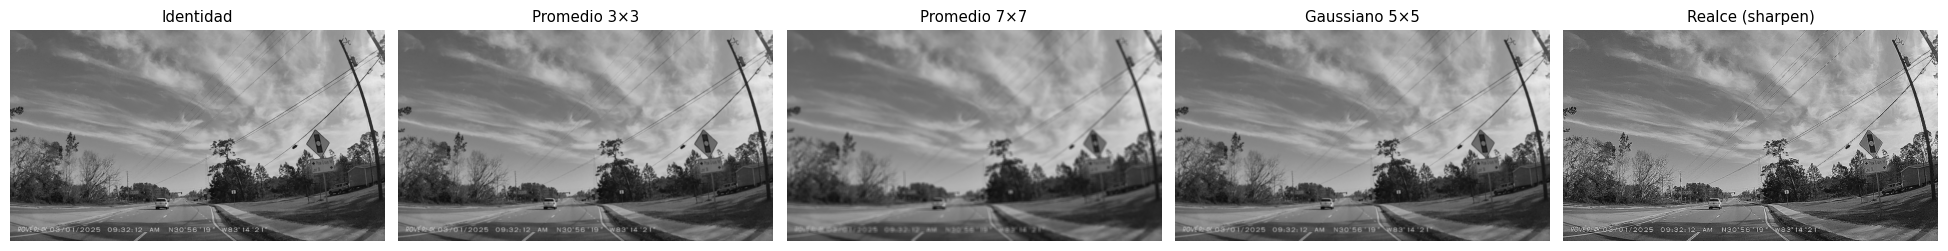

Identidad          error máximo frente a scipy.ndimage: 0.00e+00
Promedio 3×3       error máximo frente a scipy.ndimage: 0.00e+00
Promedio 7×7       error máximo frente a scipy.ndimage: 0.00e+00
Gaussiano 5×5      error máximo frente a scipy.ndimage: 0.00e+00
Realce (sharpen)   error máximo frente a scipy.ndimage: 0.00e+00


In [2]:
def correlacion(img, k):
    # Suma de productos kernel x vecindad; bordes reflejados. Un bucle sobre los k*k coeficientes, vectorizado sobre la imagen.
    H, W = img.shape; kh, kw = k.shape; ph, pw = kh // 2, kw // 2
    p = np.pad(img.astype(np.float64), ((ph, ph), (pw, pw)), mode="reflect")
    out = np.zeros((H, W))
    for i in range(kh):
        for j in range(kw):
            if k[i, j] != 0:
                out += k[i, j] * p[i:i + H, j:j + W]
    return out

def convolucion(img, k):
    return correlacion(img, k[::-1, ::-1])

# Kernels preestablecidos
promedio_3 = np.ones((3, 3)) / 9
promedio_7 = np.ones((7, 7)) / 49
gauss_5 = np.array([[1, 4, 6, 4, 1], [4, 16, 24, 16, 4], [6, 24, 36, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]]) / 256
realce_3 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
identidad = np.zeros((3, 3)); identidad[1, 1] = 1

img = cargar_gris("data/carretera.jpg")
filtros = {"Identidad": identidad, "Promedio 3×3": promedio_3, "Promedio 7×7": promedio_7, "Gaussiano 5×5": gauss_5, "Realce (sharpen)": realce_3}
salidas = {n: convolucion(img, k) for n, k in filtros.items()}
mostrar([np.clip(s, 0, 255) for s in salidas.values()], list(salidas), ncols=5, tam=3.4, vmin=0, vmax=255)

# Verificación contra SciPy (referencia independiente)
for n, k in filtros.items():
    ref = ndi.convolve(img, k, mode="mirror")     # 'mirror' de SciPy = np.pad(mode='reflect') (no repite el píxel del borde)
    print(f"{n:18s} error máximo frente a scipy.ndimage: {np.abs(salidas[n] - ref).max():.2e}")

Los filtros de promedio y gaussiano **suavizan** (bajan el ruido y también el detalle; el 7×7 borra más que el 3×3), y el de realce **acentúa los bordes** porque su coeficiente central (5) supera la suma de los vecinos negativos.
El error cero frente a SciPy confirma que la implementación es correcta.

<a id="ej1"></a>
## Ejercicio 1. Prewitt, Sobel y Laplaciano sin OpenCV

**Definiciones.**
- **Prewitt** y **Sobel** estiman el gradiente con dos kernels, uno por dirección, y la magnitud es $\|\nabla f\| = \sqrt{G_x^2 + G_y^2}$ (a veces se aproxima con $|G_x|+|G_y|$). Sobel da más peso a la fila/columna central, lo que suaviza un poco el ruido.
- El **Laplaciano** es la derivada de segundo orden $\nabla^2 f = \partial^2 f/\partial x^2 + \partial^2 f/\partial y^2$; se aproxima con un único kernel y responde a los bordes con un cruce por cero. Es isótropo, pero amplifica mucho el ruido.

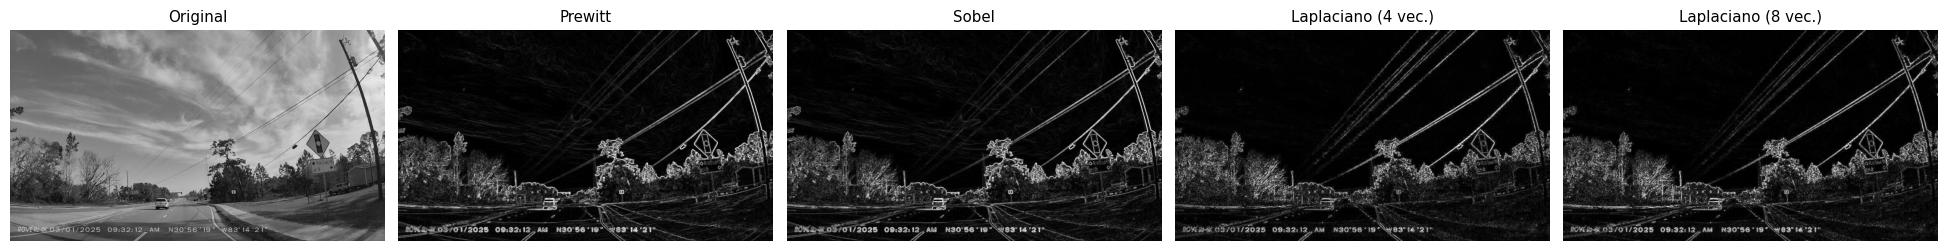

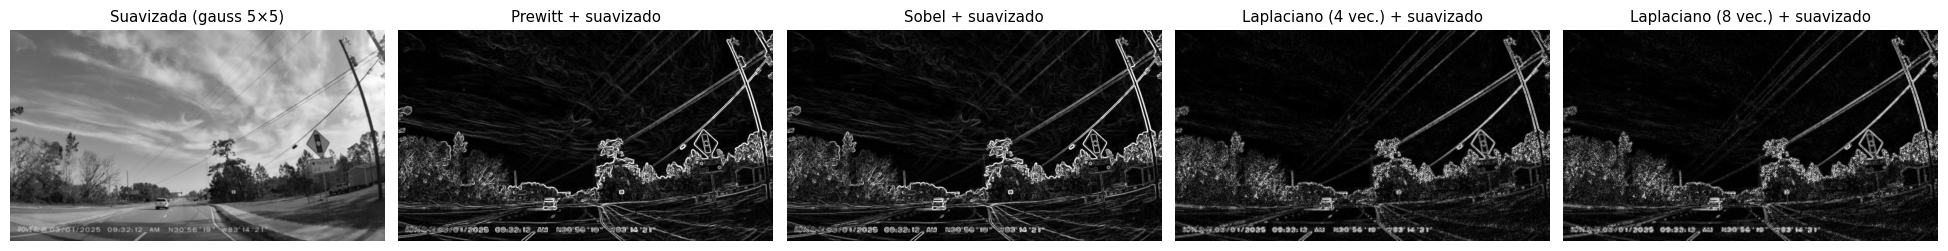

error máximo Sobel vs scipy: 0.0
error máximo Laplaciano vs scipy: 0.0


In [3]:
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], float)
prewitt_y = prewitt_x.T
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], float)
sobel_y = sobel_x.T
laplaciano_4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], float)
laplaciano_8 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], float)

def gradiente(img, kx, ky):
    gx, gy = correlacion(img, kx), correlacion(img, ky)
    return np.hypot(gx, gy), gx, gy

def prewitt(img): return gradiente(img, prewitt_x, prewitt_y)[0]
def sobel(img):   return gradiente(img, sobel_x, sobel_y)[0]
def laplaciano(img, vecinos=4): return np.abs(correlacion(img, laplaciano_4 if vecinos == 4 else laplaciano_8))

suave = correlacion(img, gauss_5)        # un suavizado previo reduce el ruido antes de derivar
res = {"Prewitt": prewitt(img), "Sobel": sobel(img), "Laplaciano (4 vec.)": laplaciano(img, 4), "Laplaciano (8 vec.)": laplaciano(img, 8)}
res_s = {"Prewitt": prewitt(suave), "Sobel": sobel(suave), "Laplaciano (4 vec.)": laplaciano(suave, 4), "Laplaciano (8 vec.)": laplaciano(suave, 8)}
def norm(x, p=99.5): return np.clip(x / np.percentile(x, p), 0, 1)
mostrar([img] + [norm(v) for v in res.values()], ["Original"] + [f"{k}" for k in res], ncols=5, tam=3.4)
mostrar([suave] + [norm(v) for v in res_s.values()], ["Suavizada (gauss 5×5)"] + [f"{k} + suavizado" for k in res_s], ncols=5, tam=3.4)

# Verificación contra SciPy
ref_sobel = np.hypot(ndi.correlate(img, sobel_x, mode="mirror"), ndi.correlate(img, sobel_y, mode="mirror"))
print("error máximo Sobel vs scipy:", np.abs(res["Sobel"] - ref_sobel).max())
print("error máximo Laplaciano vs scipy:", np.abs(res["Laplaciano (4 vec.)"] - np.abs(ndi.correlate(img, laplaciano_4, mode="mirror"))).max())

### Complejidad algorítmica

Sea $M\times N$ el número de píxeles ($n = MN$) y $k\times k$ el kernel. El costo de la convolución directa es $O(n k^2)$ multiplicaciones-suma; con $k=3$ fijo es **lineal en el número de píxeles**, $O(n)$, pero con constantes distintas:

| Detector | Kernels | Términos no nulos por píxel | Operaciones aritméticas por píxel | Extra |
|---|---|---|---|---|
| Prewitt | 2 (3×3) | 6 + 6 = 12 | 12 sumas/restas, **sin multiplicaciones** (coeficientes ±1) | magnitud: 1 raíz (o suma de valores absolutos de Gx y Gy) |
| Sobel | 2 (3×3) | 6 + 6 = 12 | 12 sumas + 4 multiplicaciones por 2 (desplazamiento de bit) | magnitud: 1 raíz (o suma de valores absolutos de Gx y Gy) |
| Laplaciano (4 vec.) | **1** (3×3) | **5** | 4 sumas + 1 multiplicación por −4 | ninguno |
| Laplaciano (8 vec.) | 1 (3×3) | 9 | 8 sumas + 1 multiplicación | ninguno |

Además, **Prewitt y Sobel son separables**: $G_x = \begin{bmatrix}1\\ 1\\ 1\end{bmatrix}\!\begin{bmatrix}-1 & 0 & 1\end{bmatrix}$ (Prewitt) o $\begin{bmatrix}1\\ 2\\ 1\end{bmatrix}\!\begin{bmatrix}-1 & 0 & 1\end{bmatrix}$ (Sobel), de modo que
se pueden aplicar como una convolución vertical seguida de una horizontal: el costo baja de $O(nk^2)$ a $O(nk)$ (6 términos en lugar de 9 por kernel). El Laplaciano de 4 vecinos no es separable como producto de dos vectores (es la *suma* de dos kernels separables).
Para kernels muy grandes, la convolución en el dominio de Fourier cuesta $O(n\log n)$ independientemente de $k$.

In [4]:
# Medición: implementación en Python puro (bucles) y en NumPy (vectorizada) sobre 256x256
def correlacion_bucles(img, k):
    H, W = img.shape; p = np.pad(img, 1, mode="reflect").tolist(); kl = k.tolist(); out = [[0.0] * W for _ in range(H)]
    nz = [(i, j, kl[i][j]) for i in range(3) for j in range(3) if kl[i][j] != 0]     # solo coeficientes no nulos
    for y in range(H):
        fila = out[y]
        for x in range(W):
            s = 0.0
            for i, j, c in nz: s += c * p[y + i][x + j]
            fila[x] = s
    return np.array(out)

chica = img[100:356, 100:356].copy()
def cronometrar(f, rep=3):
    mejor = 1e9
    for _ in range(rep):
        t0 = time.perf_counter(); f(); mejor = min(mejor, time.perf_counter() - t0)
    return mejor * 1000

filas = []
casos = {"Prewitt": lambda fn: (fn(chica, prewitt_x), fn(chica, prewitt_y)), "Sobel": lambda fn: (fn(chica, sobel_x), fn(chica, sobel_y)),
         "Laplaciano (4 vec.)": lambda fn: (fn(chica, laplaciano_4),), "Laplaciano (8 vec.)": lambda fn: (fn(chica, laplaciano_8),)}
for nombre, caso in casos.items():
    t_b = cronometrar(lambda: caso(correlacion_bucles), 1)
    t_n = cronometrar(lambda: caso(correlacion))
    filas.append((nombre, t_b, t_n))
print(f"{'detector':22s} {'Python puro (ms)':>17s} {'NumPy (ms)':>11s} {'relativo (NumPy)':>17s}")
base = min(f[2] for f in filas)
for n, tb, tn in filas: print(f"{n:22s} {tb:17.1f} {tn:11.2f} {tn / base:17.2f}x")

detector                Python puro (ms)  NumPy (ms)  relativo (NumPy)
Prewitt                             39.6        1.01              3.20x
Sobel                               40.5        0.92              2.92x
Laplaciano (4 vec.)                 16.5        0.32              1.00x
Laplaciano (8 vec.)                 27.4        0.46              1.45x


**Resultados y respuesta a «¿cuál es más eficiente?».**
- Todos son $O(n)$ para $k=3$, así que la diferencia está en la constante: el **Laplaciano de 4 vecinos es el más eficiente** (un solo kernel, 5 términos no nulos, sin raíz cuadrada), seguido del Laplaciano de 8 vecinos, y **Prewitt y Sobel cuestan entre 2 y 3 veces más** que el Laplaciano de 4 vecinos (dos kernels con 6 términos cada uno). Las mediciones lo confirman: el tiempo se ordena por número de términos no nulos, tanto en Python puro como con NumPy.
- Entre los dos de gradiente, **Prewitt es teóricamente más barato** (solo sumas y restas, sin multiplicar), pero en software con números reales la diferencia medida es indistinguible del error de medición (entre ejecuciones cambia incluso cuál de los dos sale más rápido), porque multiplicar por 2 cuesta casi lo mismo que por 1. La ventaja real de Prewitt aparecería en hardware de enteros. **Sobel suaviza mejor** el ruido porque pondera el píxel central, por lo que suele preferirse.
- Eficiencia no es calidad: el Laplaciano es el más barato pero el más sensible al ruido (ver imágenes: las zonas de textura y el cielo se llenan de respuesta) y no da dirección del borde, mientras que Sobel y Prewitt dan magnitud **y** dirección. Suavizar antes de derivar (segunda fila de imágenes) mejora sobre todo al Laplaciano.

### Extra: detectores de línea por orientación

Los operadores anteriores son detectores de *borde*. Para **líneas delgadas** (marcas de carril, por ejemplo) se usan máscaras que responden a un trazo brillante de un píxel de ancho en una orientación concreta (Gonzalez & Woods, 2018, cap. 10):

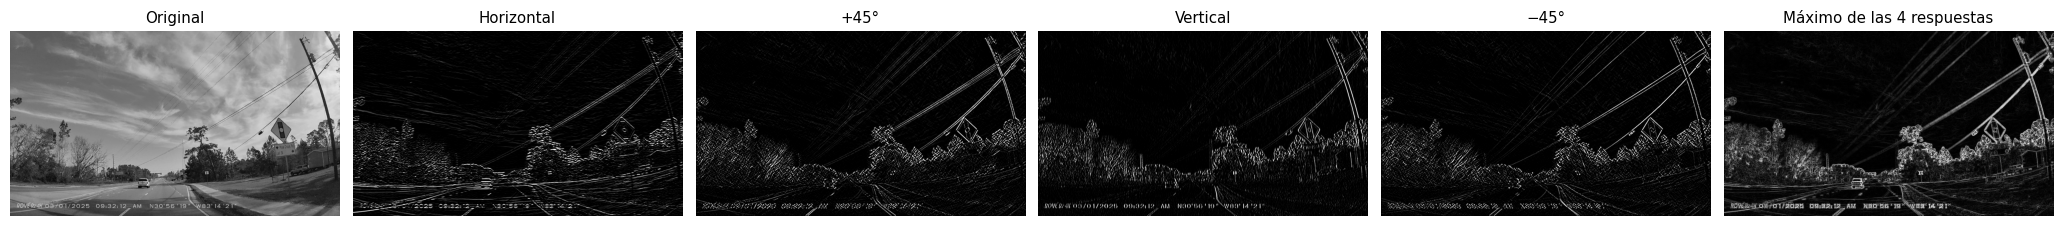

In [5]:
lineas = {"Horizontal": np.array([[-1, -1, -1], [2, 2, 2], [-1, -1, -1]], float), "+45°": np.array([[-1, -1, 2], [-1, 2, -1], [2, -1, -1]], float),
          "Vertical": np.array([[-1, 2, -1], [-1, 2, -1], [-1, 2, -1]], float), "−45°": np.array([[2, -1, -1], [-1, 2, -1], [-1, -1, 2]], float)}
resp = {n: np.maximum(correlacion(suave, k), 0) for n, k in lineas.items()}
comb = np.max(np.stack(list(resp.values())), axis=0)
mostrar([img] + [norm(v) for v in resp.values()] + [norm(comb)], ["Original"] + list(resp) + ["Máximo de las 4 respuestas"], ncols=6, tam=3.0)

<a id="ej2"></a>
## Ejercicio 2. Realce restando la imagen de líneas multiplicada por α

**Idea.** Se extrae una imagen de «líneas» $L$ (aquí, el Laplaciano) y se combina con la original: $g = f - \alpha\, L$. Con el kernel Laplaciano de centro negativo, restar $L$ **suma** un realce proporcional a la curvatura local,
lo que agudiza los bordes. El factor $\alpha > 1$ multiplica la máscara de líneas para reforzarla; $\alpha = 1$ es el realce estándar de Gonzalez y Woods (2018), y valores mayores dan un realce más agresivo con riesgo de *halos* y de amplificar el ruido.

Se prueba con una imagen algo desenfocada (para que el realce tenga qué recuperar) y con una imagen con ruido añadido (para observar el costo).

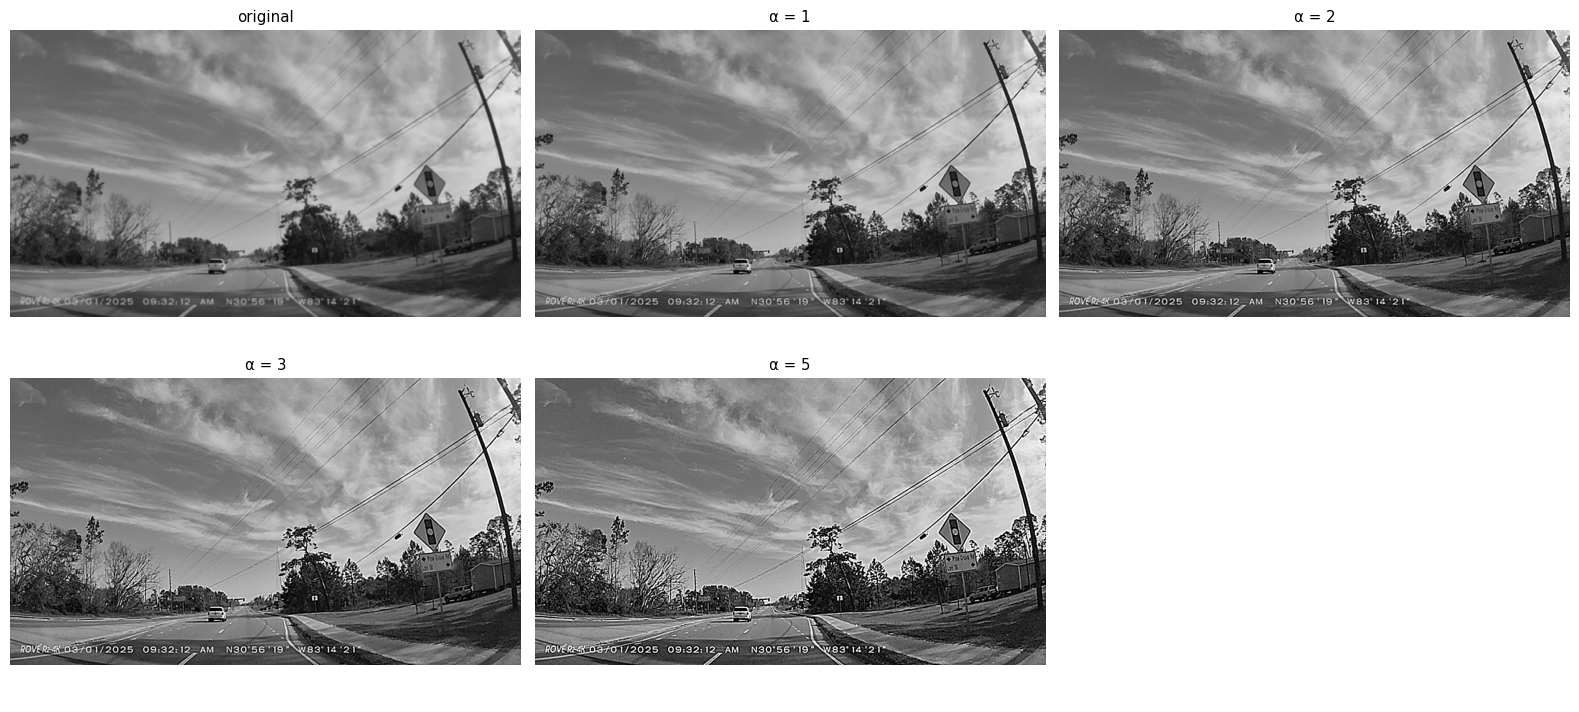

Imagen desenfocada
    α  nitidez (var. Laplaciano)   % píxeles con cambio >60
    0                       56.0                       0.00
    1                      368.6                       0.04
    2                      967.2                       1.23
    3                     1771.9                       3.23
    5                     3656.2                       6.97


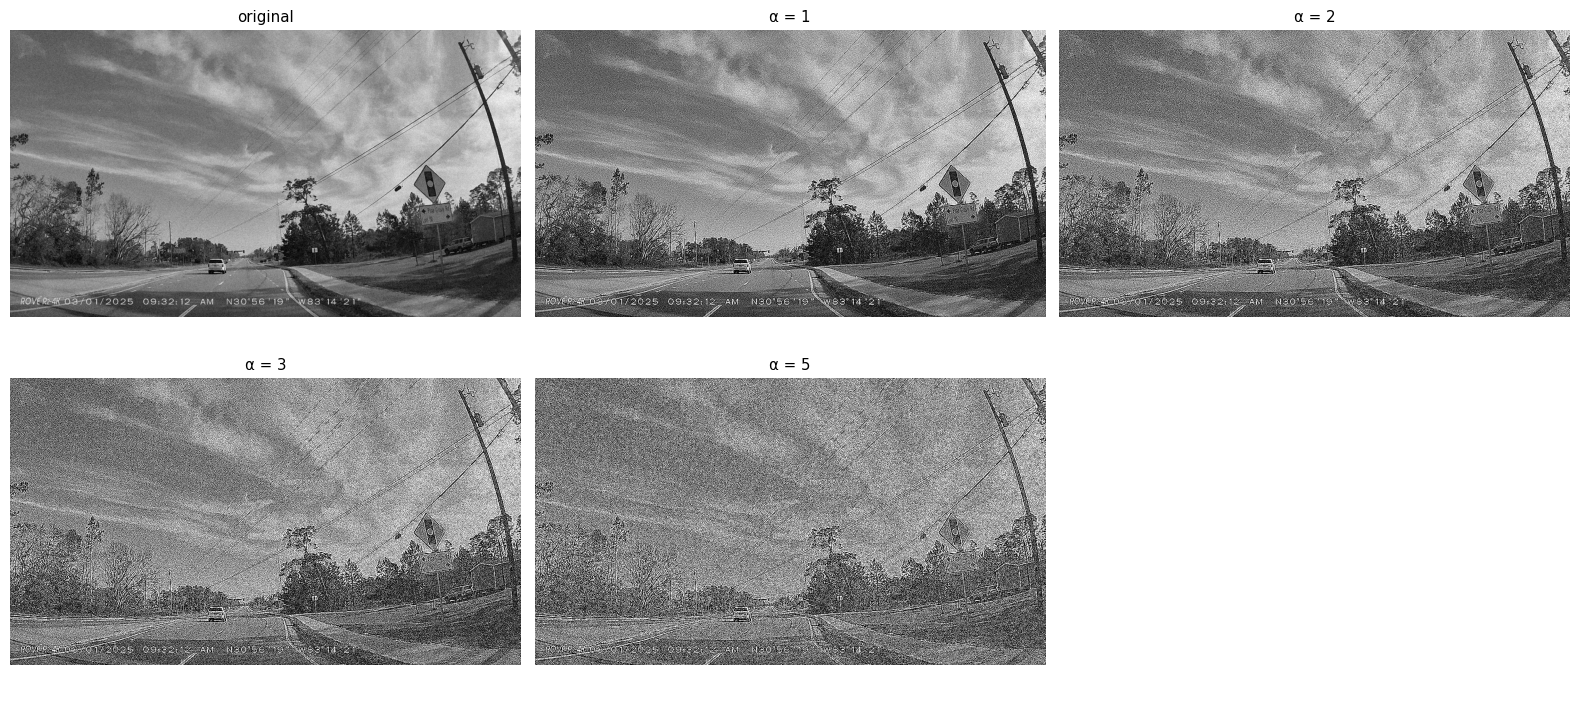

Imagen con ruido gaussiano (σ=8)
    α  nitidez (var. Laplaciano)   % píxeles con cambio >60
    0                     3214.7                       0.00
    1                    72396.5                      14.19
    2                   162243.4                      39.85
    3                   231719.8                      53.45
    5                   309625.6                      65.91


In [6]:
def realzar(img, alfa, kernel=laplaciano_4):
    L = correlacion(img, kernel)               # imagen de líneas / curvatura (centro negativo)
    return np.clip(img - alfa * L, 0, 255)

def nitidez(g):        # varianza del Laplaciano: mayor = más borde/detalle (también sube con el ruido)
    return float(correlacion(g, laplaciano_4).var())

def sobrepaso(g, ref): # % de píxeles que se salen del rango original antes de recortar (halos)
    return float(np.mean(np.abs(g - ref) > 60) * 100)

rng = np.random.default_rng(0)
desenfocada = correlacion(img, gauss_5)
ruidosa = np.clip(img + rng.normal(0, 8, img.shape), 0, 255)
alfas = [0, 1, 2, 3, 5]
for nombre, base_img in (("desenfocada", desenfocada), ("con ruido gaussiano (σ=8)", ruidosa)):
    salidas = [realzar(base_img, a) for a in alfas]
    mostrar(salidas, [("original" if a == 0 else f"α = {a}") for a in alfas], ncols=3, tam=4.6, vmin=0, vmax=255)
    print(f"Imagen {nombre}")
    print(f"  {'α':>3s} {'nitidez (var. Laplaciano)':>26s} {'% píxeles con cambio >60':>26s}")
    for a, s in zip(alfas, salidas): print(f"  {a:3d} {nitidez(s):26.1f} {sobrepaso(s, base_img):26.2f}")

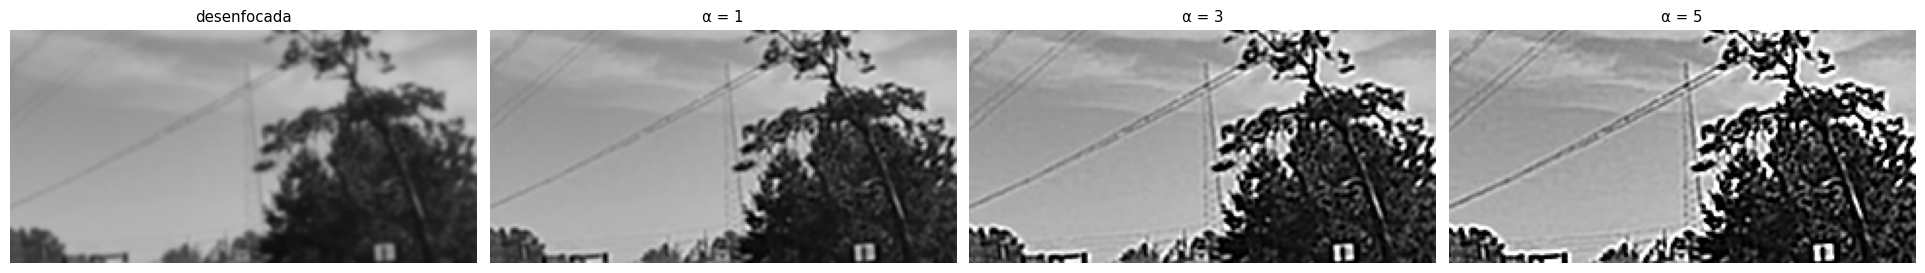

In [7]:
# Vista ampliada de un recorte para apreciar los halos alrededor de los bordes
y0, y1, x0, x1 = 300, 420, 380, 620
mostrar([desenfocada[y0:y1, x0:x1]] + [realzar(desenfocada, a)[y0:y1, x0:x1] for a in (1, 3, 5)], ["desenfocada", "α = 1", "α = 3", "α = 5"], ncols=4, tam=4.2, vmin=0, vmax=255)

<a id="ej3"></a>
## Ejercicio 3. Aplicación médica: gammagrafía ósea con varias etapas

**Aplicación.** Una gammagrafía ósea de cuerpo entero (medicina nuclear) es una imagen de **bajo contraste y mucho ruido** en la que hay que localizar zonas pequeñas de captación anormal.
Gonzalez y Woods (2018) proponen combinar varias técnicas espaciales, cada una con una función:

| Etapa | Operación | Para qué |
|---|---|---|
| (a) | Imagen original | — |
| (b) | Laplaciano de (a) | Resalta detalles finos (pero también ruido) |
| (c) | (a) + (b) con centro negativo → $a - b$ | Imagen agudizada |
| (d) | Gradiente de Sobel de (a) | Bordes fuertes, menos sensible al ruido que el Laplaciano |
| (e) | (d) suavizado con un promedio 5×5 | Mapa de bordes «robusto», que ignora el grano |
| (f) | Máscara = (c) × (e) | Solo conserva el realce donde hay bordes fuertes |
| (g) | (a) + (f) | Imagen realzada con detalle sin amplificar el ruido de las zonas planas |
| (h) | Transformación de potencia sobre (g) | Amplía el rango dinámico (γ < 1 aclara las zonas de baja captación) |

Se aplica a una gammagrafía de cuerpo entero (vistas anterior y posterior; CC BY-SA 3.0, ver `LICENCIAS.md`), sin flechas de anotación e invertida para que el hueso con captación quede claro sobre fondo oscuro.

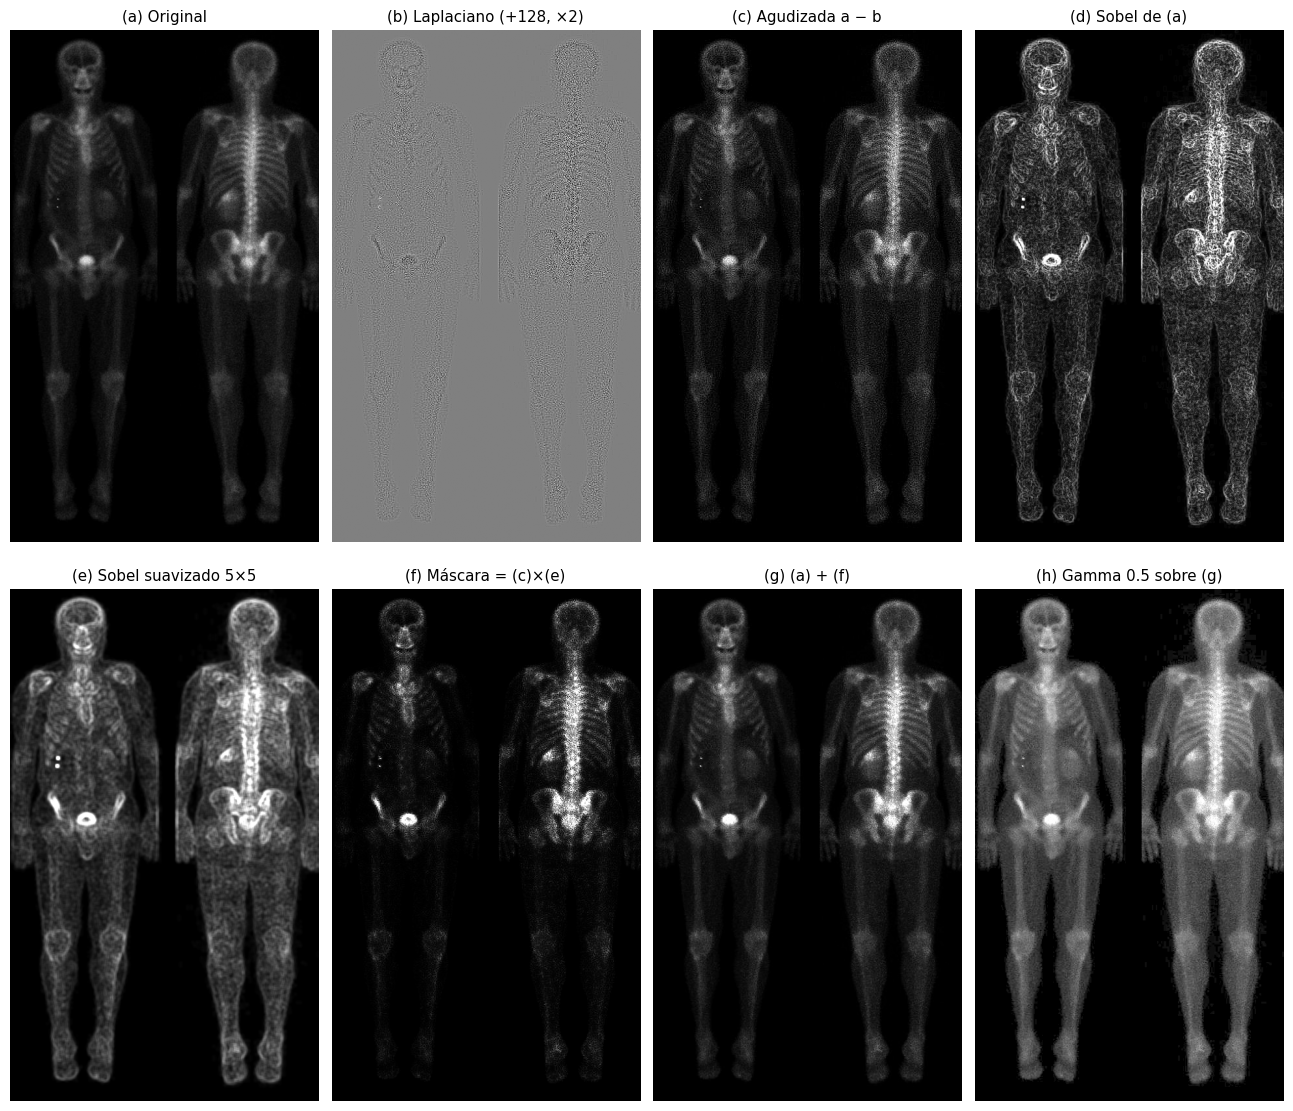

In [8]:
a = cargar_gris("data/gammagrafia_osea.png")
b = correlacion(a, laplaciano_4)
c = np.clip(a - b, 0, 255)                                   # (a) + realce Laplaciano (centro negativo)
d = np.hypot(correlacion(a, sobel_x), correlacion(a, sobel_y))
e = correlacion(d, np.ones((5, 5)) / 25)
e_n = e / e.max()                                            # máscara normalizada a [0, 1]
f = c * e_n
g = np.clip(a + f, 0, 255)
h = 255 * (g / 255) ** 0.5                                   # γ = 0.5, c = 1
def ver(x): return np.clip(x, 0, 255)
paneles = [a, ver(128 + b * 2), c, 255 * norm(d), 255 * norm(e), 255 * norm(f), g, h]   # las etapas normalizadas a [0,1] se llevan a 0-255
mostrar(paneles, ["(a) Original", "(b) Laplaciano (+128, ×2)", "(c) Agudizada a − b", "(d) Sobel de (a)", "(e) Sobel suavizado 5×5", "(f) Máscara = (c)×(e)", "(g) (a) + (f)", "(h) Gamma 0.5 sobre (g)"],
        ncols=4, vmin=0, vmax=255, figsize=(13, 11.5))

etapa                            media   desv.    nitidez  grano (cuerpo)
(a) original                      17.7    26.1      150.8            5.71
(c) agudizada a − b               18.1    29.9     3823.4           21.75
(g) a + máscara                   21.3    34.5      786.8           10.98
(h) gamma 0.5                     50.7    53.5      768.7           10.81


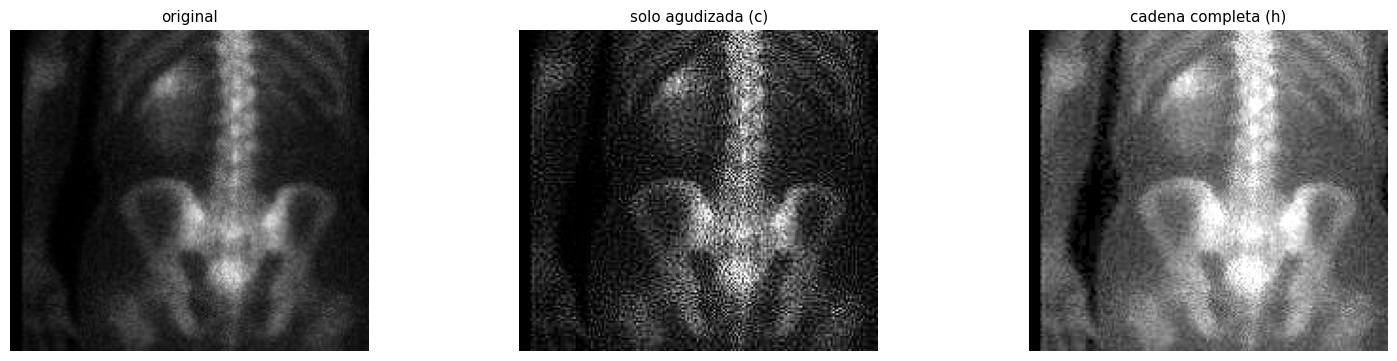

In [9]:
def resumen(x):
    return dict(media=x.mean(), desv=x.std(), p99=np.percentile(x, 99.5), nitidez=nitidez(x),
                ruido=float(np.std((x - ndi.uniform_filter(x, 5))[a > 12])))   # grano de alta frecuencia dentro del cuerpo (a > 12)
print(f"{'etapa':30s} {'media':>7s} {'desv.':>7s} {'nitidez':>10s} {'grano (cuerpo)':>15s}")
for nombre, x in (("(a) original", a), ("(c) agudizada a − b", c), ("(g) a + máscara", g), ("(h) gamma 0.5", h)):
    r = resumen(x); print(f"{nombre:30s} {r['media']:7.1f} {r['desv']:7.1f} {r['nitidez']:10.1f} {r['ruido']:15.2f}")

# Recorte ampliado de columna vertebral / pelvis (vista posterior): original vs (c) vs (h)
y0, y1, x0, x1 = 230, 400, 250, 440
mostrar([a[y0:y1, x0:x1], c[y0:y1, x0:x1], h[y0:y1, x0:x1]], ["original", "solo agudizada (c)", "cadena completa (h)"], ncols=3, tam=4.6, vmin=0, vmax=255)

<a id="conclusion"></a>
## Conclusión


- **La convolución es una sola operación con muchos usos.** Cambiando únicamente el kernel se obtiene suavizado (promedio, gaussiano), realce, gradiente (Prewitt, Sobel), segunda derivada (Laplaciano) o detección de líneas por orientación.
  La implementación propia (un bucle sobre los coeficientes del kernel, vectorizado sobre la imagen) coincide exactamente con SciPy (error 0) una vez que se usa la misma definición de borde; con definiciones distintas aparecen diferencias solo en la orilla.
- **Eficiencia (ejercicio 1).** Con kernel 3×3 todos son lineales en el número de píxeles. El Laplaciano de 4 vecinos es el más barato (un kernel, 5 términos no nulos): entre 2 y 3 veces más rápido que Prewitt o Sobel en las mediciones, tanto en Python puro como con NumPy.
  Entre Prewitt y Sobel la diferencia medida no es significativa en software. La eficiencia no equivale a calidad: el Laplaciano es el más sensible al ruido y no da dirección, por lo que conviene suavizar antes de derivar.
- **Realce por diferencia (ejercicio 2).** Restar α veces la imagen de líneas aumenta la nitidez de forma casi lineal con α: en la imagen desenfocada, la varianza del Laplaciano pasa de 56 (sin realce) a 369 con α=1 y a 3 656 con α=5, pero la fracción de píxeles que cambian más de 60 niveles (halos y sobrepasos) sube de 0.04 % a 7 %.
  En una imagen con ruido gaussiano (σ=8) el mismo realce es destructivo: la nitidez medida se multiplica por 22 con α=1, porque en gran parte es ruido amplificado, y con α=5 cambian más de 60 niveles el 66 % de los píxeles. El factor α>1 solo es razonable sobre imágenes limpias o previamente suavizadas.
- **Mejora médica en varias etapas (ejercicio 3).** Agudizar la gammagrafía solo con el Laplaciano (etapa c) multiplica por casi 4 el grano dentro del cuerpo (de 5.7 a 21.8). Al combinarla con la máscara de bordes suavizada de Sobel (etapas e–g), el realce se concentra donde hay estructura y el grano solo se duplica (11.0), a cambio de un realce menor (nitidez 787 frente a 3 823).
  La transformación de potencia final (γ=0.5) eleva el brillo medio de 21 a 51 y hace visibles zonas de baja captación que antes se perdían en el fondo oscuro. Cada etapa resuelve un problema distinto (detalle, ruido, rango dinámico), y el orden importa.
- **Limitaciones.** La gammagrafía usada es de baja resolución (501×845 px) y solo sirve para ilustrar la técnica: no se evaluó con criterio clínico. Las métricas de nitidez (varianza del Laplaciano) suben también con el ruido, por lo que siempre se acompañaron de una medida de grano o de cambio de píxeles.
- **Sobre el material.** La carpeta de la actividad solo traía las diapositivas de convolución, por lo que el notebook se construyó completo.


## Referencias

- Gonzalez, R. C., & Woods, R. E. (2018). *Digital image processing* (4.ª ed.). Pearson. (Cap. 3 y 10.)
- Sobel, I., & Feldman, G. (1968). *A 3x3 isotropic gradient operator for image processing* [Presentación]. Stanford Artificial Intelligence Project (SAIL).
- Prewitt, J. M. S. (1970). Object enhancement and extraction. En B. S. Lipkin & A. Rosenfeld (Eds.), *Picture processing and psychopictorics* (pp. 75–149). Academic Press.
- Stanford Vision Lab. (s. f.). *Convolution* [Tutorial]. https://ai.stanford.edu/~syyeung/cvweb/tutorial1.html
- Rosebrock, A. (2016, 25 de julio). Convolutions with OpenCV and Python. *PyImageSearch*. https://pyimagesearch.com/2016/07/25/convolutions-with-opencv-and-python
- van der Walt, S., Colbert, S. C., & Varoquaux, G. (2011). The NumPy array: A structure for efficient numerical computation. *Computing in Science & Engineering, 13*(2), 22–30. https://doi.org/10.1109/MCSE.2011.37
- Imágenes: ver `LICENCIAS.md` (Wikimedia Commons: Rivera, CC0; Hg6996, CC BY-SA 3.0).
